In [ ]:
!pip install matplotlib

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from airsenal.scripts.replay_season import rerun_predictions
from airsenal.framework.prediction_utils import get_player_scores
from airsenal.framework.utils import session
from airsenal.framework.schema import Fixture, PlayerScore, Player, PlayerPrediction

/home/mnegm/anaconda3/envs/airsenalenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generate Predictions (slow!)

In [59]:
season = "2425"
gw_start = 1
gw_end = 1

weeks_ahead = 12
num_thread = 1

Run outside this notebook:
```
rerun_predictions(
    season=season,
    gw_start=gw_start,
    gw_end=gw_end,
    weeks_ahead=weeks_ahead, 
    num_thread=num_thread,
)
```

## Get Players from Database

In [60]:
players = pd.read_sql(session.query(Player).statement, session.bind)
players.set_index("player_id", inplace=True)
players = players["name"]
players.head()

player_id
1           Fábio Ferreira Vieira
2       Gabriel Fernando de Jesus
3    Gabriel dos Santos Magalhães
4                     Kai Havertz
5                       Karl Hein
Name: name, dtype: object

## Get Predictions from the Database

In [61]:
gw = 1

In [70]:
preds = pd.read_sql(session.query(PlayerPrediction).statement, session.bind)

tags = preds["tag"].unique().astype(str)
tags

array(['2425_1_9d9be714-f0ab-4acd-9d0f-42c20175bcb1',
       '2425_2_62f42548-5b31-455a-8875-bd997539a349',
       '2425_3_58ad75ad-501c-4e4e-aa22-2ed92fcc905a',
       '2425_4_9571d90c-99a4-4d71-89d3-83ac602df701',
       '2425_5_204e1b2b-88f3-49d3-b370-26904c6c52f1',
       '2425_6_6d28b964-bf5c-4755-ba84-c22854a0bba3',
       '2425_7_51605bf0-9eb1-4fad-9cd9-00fc4c15bbb9',
       '2425_8_b98ae43f-5e9b-4f5b-8120-cece5383827d',
       '2425_9_40bbad5d-2921-4a17-83a9-525dd5eb2924',
       '2425_10_521c2b1c-d1a0-4164-9664-1f3eff3e2027',
       '2425_11_aae4569f-87ce-4678-8b5d-c9fdb7bf7642',
       '2425_12_87c83e45-b5e4-4d5a-a623-73db4785e4a7'], dtype='<U44')

In [71]:
gw_tag = tags[np.char.startswith(tags, f"{season}_{gw}_")][0]

gw_preds = preds[preds["tag"] == gw_tag]
gw_preds.head()

,id,fixture_id,predicted_points,tag,player_id
0,7393,9,5.654568,2425_1_9d9be714-f0ab-4acd-9d0f-42c20175bcb1,414
1,7394,14,8.138942,2425_1_9d9be714-f0ab-4acd-9d0f-42c20175bcb1,414
2,7395,27,6.137739,2425_1_9d9be714-f0ab-4acd-9d0f-42c20175bcb1,414
3,7396,2,7.269857,2425_1_9d9be714-f0ab-4acd-9d0f-42c20175bcb1,390
4,7397,20,6.990348,2425_1_9d9be714-f0ab-4acd-9d0f-42c20175bcb1,390


In [72]:
# Group by 'player_id' and calculate the sum of 'predicted_points'
sum_predicted_points_by_player = preds.groupby('player_id')['predicted_points'].sum()

# Display the sum for each player
sum_predicted_points_by_player


#Get the sum of predicted points for a specific player (e.g., player_id = 414)
specific_player_id = 414
player_predicted_points = preds[preds['player_id'] == specific_player_id]['predicted_points'].sum()

print(f"Sum of predicted points for player with ID {specific_player_id}: {player_predicted_points}")


Sum of predicted points for player with ID 414: 282.91652631759644


In [73]:
tags

array(['2425_1_9d9be714-f0ab-4acd-9d0f-42c20175bcb1',
       '2425_2_62f42548-5b31-455a-8875-bd997539a349',
       '2425_3_58ad75ad-501c-4e4e-aa22-2ed92fcc905a',
       '2425_4_9571d90c-99a4-4d71-89d3-83ac602df701',
       '2425_5_204e1b2b-88f3-49d3-b370-26904c6c52f1',
       '2425_6_6d28b964-bf5c-4755-ba84-c22854a0bba3',
       '2425_7_51605bf0-9eb1-4fad-9cd9-00fc4c15bbb9',
       '2425_8_b98ae43f-5e9b-4f5b-8120-cece5383827d',
       '2425_9_40bbad5d-2921-4a17-83a9-525dd5eb2924',
       '2425_10_521c2b1c-d1a0-4164-9664-1f3eff3e2027',
       '2425_11_aae4569f-87ce-4678-8b5d-c9fdb7bf7642',
       '2425_12_87c83e45-b5e4-4d5a-a623-73db4785e4a7'], dtype='<U44')

## Get Actual Scores from the Database

In [74]:
query = (
    session.query(PlayerScore, Fixture.season, Fixture.gameweek)
    .filter(Fixture.gameweek >= gw)
    .filter(Fixture.gameweek < gw + weeks_ahead)
    .filter(Fixture.season == season)
    .join(Fixture)
)
scores = pd.read_sql(query.statement, session.bind)
scores.set_index("id", inplace=True, drop=True)
scores = scores.merge(players, left_on="player_id", right_index=True)

scores.head()

,player_team,opponent,points,goals,assists,bonus,conceded,minutes,player_id,result_id,...,creativity,threat,ict_index,expected_goals,expected_assists,expected_goal_involvements,expected_goals_conceded,season,gameweek,name
id,,,,,,,,,,,,,,,,,,,,,
1,ARS,WOL,0,0,0,0,0,0,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2425,1,Fábio Ferreira Vieira
2,ARS,AVL,0,0,0,0,0,0,1,17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2425,2,Fábio Ferreira Vieira
3,ARS,BHA,0,0,0,0,0,0,1,21,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2425,3,Fábio Ferreira Vieira
4,ARS,TOT,0,0,0,0,0,0,1,39,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2425,4,Fábio Ferreira Vieira
5,ARS,MCI,0,0,0,0,0,0,1,50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2425,5,Fábio Ferreira Vieira


In [75]:
scores[["name", "points"]].sort_values(by="points", ascending=False).head()

,name,points
id,,
1189,Cole Palmer,25
1155,Noni Madueke,20
86094,Michail Antonio,18
1185,Cole Palmer,17
2401,Erling Haaland,17


In [76]:
scores = scores.merge(
    gw_preds,
    left_on=["player_id", "fixture_id"],
    right_on=["player_id", "fixture_id"]
)

scores.head()

,player_team,opponent,points,goals,assists,bonus,conceded,minutes,player_id,result_id,...,expected_goals,expected_assists,expected_goal_involvements,expected_goals_conceded,season,gameweek,name,id,predicted_points,tag
0,ARS,WOL,0,0,0,0,0,0,1,3,...,0.0,0.0,0.0,0.00,2425,1,Fábio Ferreira Vieira,7675,1.022316,2425_1_9d9be714-f0ab-4acd-9d0f-42c20175bcb1
1,ARS,AVL,0,0,0,0,0,0,1,17,...,0.0,0.0,0.0,0.00,2425,2,Fábio Ferreira Vieira,7676,1.016376,2425_1_9d9be714-f0ab-4acd-9d0f-42c20175bcb1
2,ARS,BHA,0,0,0,0,0,0,1,21,...,0.0,0.0,0.0,0.00,2425,3,Fábio Ferreira Vieira,7677,1.022175,2425_1_9d9be714-f0ab-4acd-9d0f-42c20175bcb1
3,ARS,WOL,0,0,0,0,0,5,2,3,...,0.0,0.0,0.0,0.15,2425,1,Gabriel Fernando de Jesus,7462,2.131273,2425_1_9d9be714-f0ab-4acd-9d0f-42c20175bcb1
4,ARS,AVL,0,0,0,0,0,0,2,17,...,0.0,0.0,0.0,0.00,2425,2,Gabriel Fernando de Jesus,7463,1.867280,2425_1_9d9be714-f0ab-4acd-9d0f-42c20175bcb1


Text(0.5, 1.0, '2425 GW 1 - GW 12')

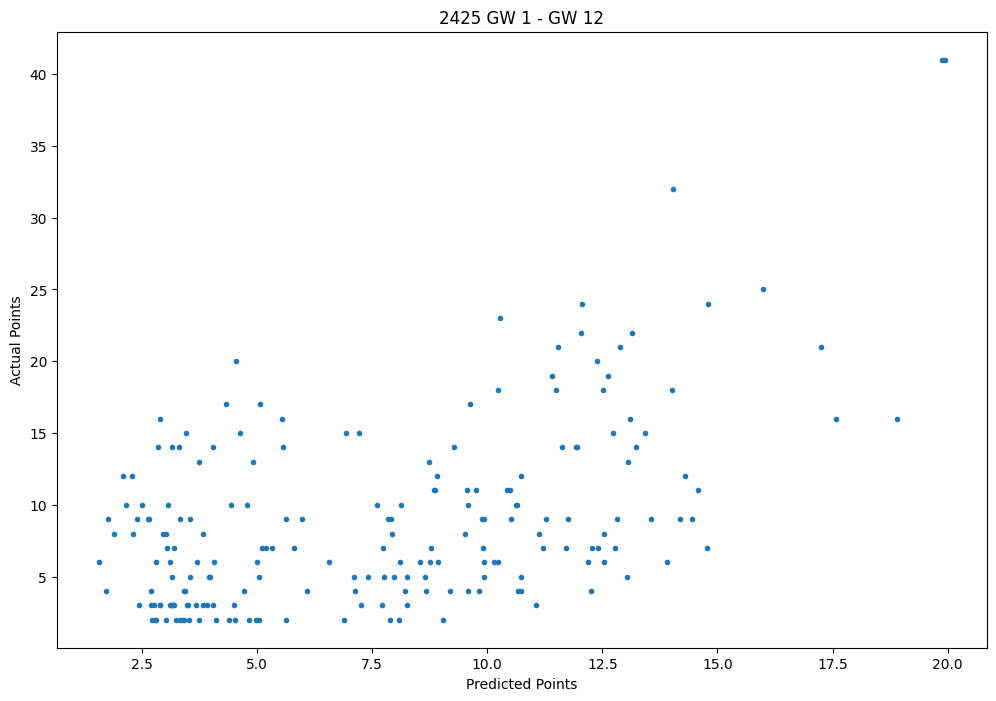

In [77]:
sum_pts = scores.groupby("name")[["points", "predicted_points"]].sum()

mask = (sum_pts["points"] > 1) & (sum_pts["predicted_points"] > 1)

plt.figure(figsize=(12, 8))
plt.plot(sum_pts[mask]["predicted_points"], sum_pts[mask]["points"], ".")
plt.xlabel("Predicted Points")
plt.ylabel("Actual Points")
plt.title(f"{season} GW {gw} - GW {gw+weeks_ahead-1}")

In [78]:
sum_pts.corr()

,points,predicted_points
points,1.000000,0.584061
predicted_points,0.584061,1.000000


In [79]:
sum_pts.head()

,points,predicted_points
name,,
Aaron Cresswell,1,2.871986
Aaron Hickey,0,0.000000
Aaron Ramsdale,0,0.000000
Aaron Wan-Bissaka,2,0.000000
Abdoulaye Doucouré,4,10.731706


In [80]:
sum_pts

,points,predicted_points
name,,
Aaron Cresswell,1,2.871986
Aaron Hickey,0,0.000000
Aaron Ramsdale,0,0.000000
Aaron Wan-Bissaka,2,0.000000
Abdoulaye Doucouré,4,10.731706
...,...,...
Yves Bissouma,10,2.503125
Álex Moreno Lopera,0,0.000000
Ângelo Gabriel Borges Damaceno,0,0.000000


In [43]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

mae = mean_absolute_error(sum_pts['points'], sum_pts['predicted_points'])
print(f"Mean Absolute Error (MAE): {mae:.2f}")
mse = mean_squared_error(sum_pts['points'], sum_pts['predicted_points'])
print(f"Mean Squared Error (MSE): {mse:.2f}")
rmse = mean_squared_error(sum_pts['points'], sum_pts['predicted_points'], squared=False)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
mape = ((sum_pts['points'] - sum_pts['predicted_points']).abs() / sum_pts['points'].clip(lower=1)).mean() * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")




Mean Absolute Error (MAE): 3.10
Mean Squared Error (MSE): 22.61
Root Mean Squared Error (RMSE): 4.75
Mean Absolute Percentage Error (MAPE): 119.05%


/home/mnegm/anaconda3/envs/airsenalenv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [16]:
from scipy.stats import pearsonr

pearson_corr, _ = pearsonr(sum_pts['points'], sum_pts['predicted_points'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.2f}")


Pearson Correlation Coefficient: 0.58


In [17]:
from scipy.stats import spearmanr

spearman_corr, _ = spearmanr(sum_pts['points'], sum_pts['predicted_points'])
print(f"Spearman Rank Correlation: {spearman_corr:.2f}")


Spearman Rank Correlation: 0.48


In [18]:
sum_pts['residuals'] = sum_pts['points'] - sum_pts['predicted_points']


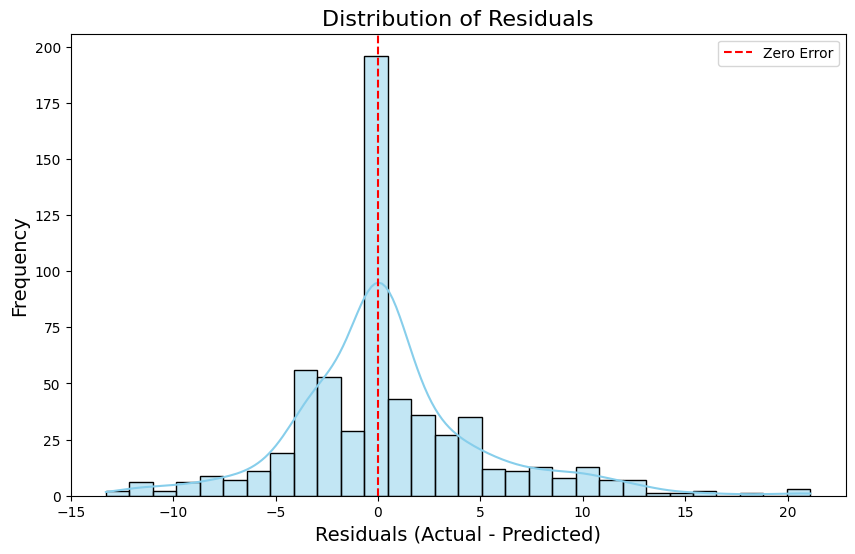

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(sum_pts['residuals'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Residuals', fontsize=16)
plt.xlabel('Residuals (Actual - Predicted)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.legend()
plt.show()


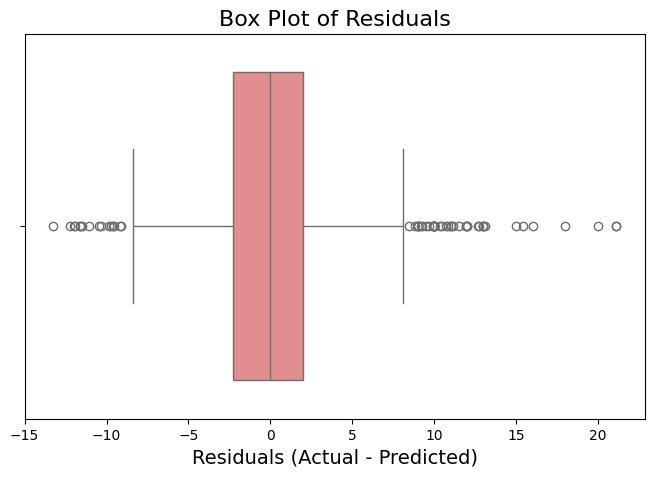

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=sum_pts['residuals'], color='lightcoral')
plt.title('Box Plot of Residuals', fontsize=16)
plt.xlabel('Residuals (Actual - Predicted)', fontsize=14)
plt.show()


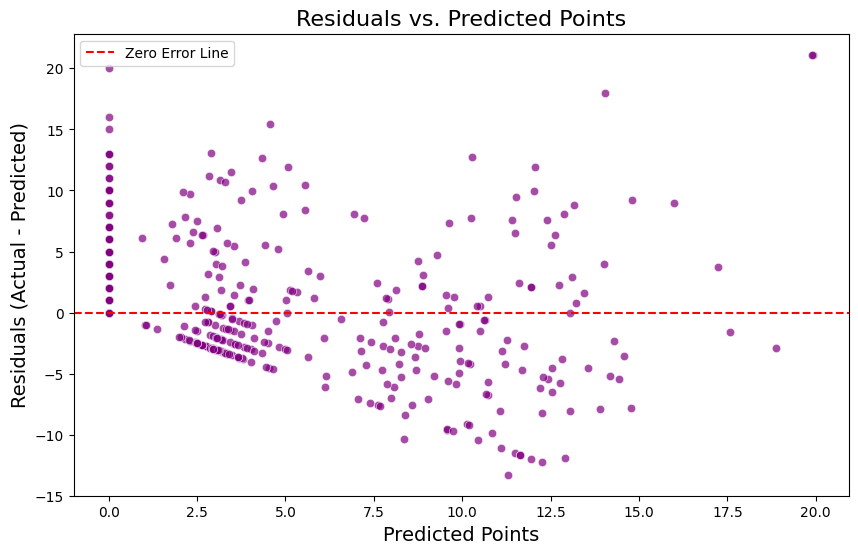

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=sum_pts['predicted_points'], y=sum_pts['residuals'], alpha=0.7, color='purple')
plt.axhline(0, color='red', linestyle='--', label='Zero Error Line')
plt.title('Residuals vs. Predicted Points', fontsize=16)
plt.xlabel('Predicted Points', fontsize=14)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=14)
plt.legend()
plt.show()


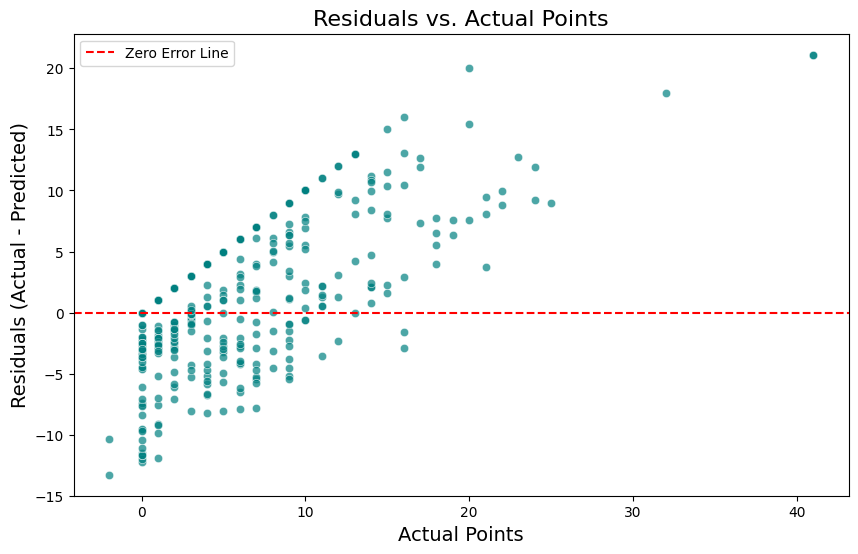

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=sum_pts['points'], y=sum_pts['residuals'], alpha=0.7, color='teal')
plt.axhline(0, color='red', linestyle='--', label='Zero Error Line')
plt.title('Residuals vs. Actual Points', fontsize=16)
plt.xlabel('Actual Points', fontsize=14)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=14)
plt.legend()
plt.show()


In [ ]:
threshold = 55 # Adjust this based on the dataset
high_scorers = sum_pts[sum_pts['points'] >= threshold]
low_scorers = sum_pts[sum_pts['points'] < threshold]

high_mae = mean_absolute_error(high_scorers['points'], high_scorers['predicted_points'])
low_mae = mean_absolute_error(low_scorers['points'], low_scorers['predicted_points'])

print(f"High Scorers MAE: {high_mae:.2f}")
print(f"Low Scorers MAE: {low_mae:.2f}")


In [ ]:
sum_pts[mask].sort_values(by="points",  ascending=False).head(30)

In [ ]:
pip install scikit-learn

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(sum_pts[mask]['points'], sum_pts[mask]['predicted_points'])
rmse = mean_squared_error(sum_pts[mask]['points'], sum_pts[mask]['predicted_points'], squared=False)
r2 = r2_score(sum_pts[mask]['points'], sum_pts[mask]['predicted_points'])

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")


In [ ]:
from scipy.stats import zscore

# Calculate Z-scores for the points and predicted_points
sum_pts['z_points'] = zscore(sum_pts['points'])
sum_pts['z_predicted_points'] = zscore(sum_pts['predicted_points'])

# Define outlier threshold (e.g., 3 or -3)
threshold = 3

# Filter rows where Z-score is greater than the threshold (outliers)
outliers = sum_pts[(sum_pts['z_points'].abs() > threshold) | (sum_pts['z_predicted_points'].abs() > threshold)]

print(outliers)



In [ ]:
pip install seaborn

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting boxplot for points and predicted points
plt.figure(figsize=(12, 6))
sns.boxplot(data=[sum_pts['points'], sum_pts['predicted_points']], orient='v')
plt.xticks([0, 1], ['Actual Points', 'Predicted Points'])
plt.title('Boxplot for Points and Predicted Points')
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Scatter plot of predicted vs actual points
plt.scatter(sum_pts['predicted_points'], sum_pts['points'])
plt.xlabel('Predicted Points')
plt.ylabel('Actual Points')
plt.title('Predicted vs Actual Points')
plt.show()

# Plotting residuals (errors)
residuals = sum_pts['points'] - sum_pts['predicted_points']
plt.scatter(sum_pts['predicted_points'], residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Points')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()


In [ ]:
# Filter out rows where actual points are zero to avoid division by zero
sum_pts_non_zero = sum_pts[sum_pts['points'] != 0]

# Calculate MAPE (Mean Absolute Percentage Error)
# Inspect the errors between predicted and actual points
sum_pts_non_zero['error'] = abs(sum_pts_non_zero['points'] - sum_pts_non_zero['predicted_points'])
print(sum_pts_non_zero[['points', 'predicted_points', 'error']].sort_values(by='error', ascending=False).head())




In [ ]:
sum_pts

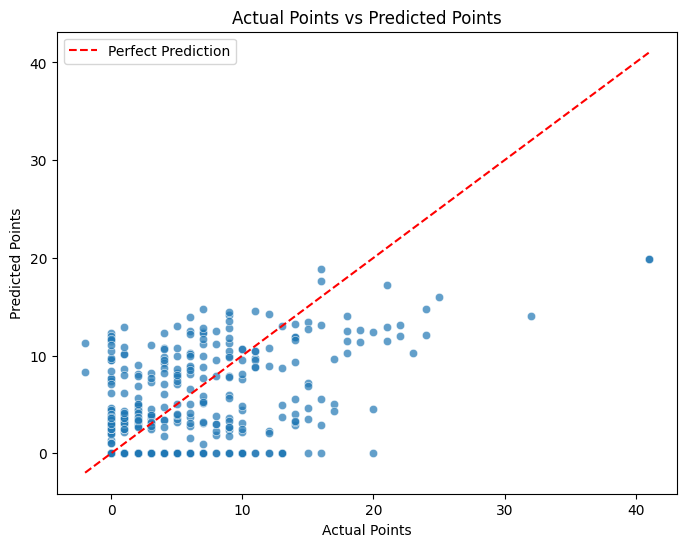

KeyError: 'residuals'

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter Plot: Actual Points vs Predicted Points
plt.figure(figsize=(8, 6))
sns.scatterplot(x=sum_pts['points'], y=sum_pts['predicted_points'], alpha=0.7)
plt.plot([sum_pts['points'].min(), sum_pts['points'].max()], 
         [sum_pts['points'].min(), sum_pts['points'].max()], 
         color='red', linestyle='--', label='Perfect Prediction')
plt.title("Actual Points vs Predicted Points")
plt.xlabel("Actual Points")
plt.ylabel("Predicted Points")
plt.legend()
plt.show()

# Bar Plot: Top 10 Players by Residuals
top_residuals = sum_pts.sort_values('residuals', key=abs, ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_residuals.index, y=top_residuals['residuals'], palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Players by Residuals")
plt.ylabel("Residuals (Actual - Predicted)")
plt.xlabel("Player Name")
plt.show()

# Cumulative Points Comparison
sum_pts['cumulative_points'] = sum_pts['points'].cumsum()
sum_pts['cumulative_predicted'] = sum_pts['predicted_points'].cumsum()
plt.figure(figsize=(10, 6))
plt.plot(sum_pts['cumulative_points'], label='Cumulative Actual Points', marker='o')
plt.plot(sum_pts['cumulative_predicted'], label='Cumulative Predicted Points', marker='o', linestyle='--')
plt.title("Cumulative Points Comparison")
plt.xlabel("Players (Index)")
plt.ylabel("Points")
plt.legend()
plt.show()

# Heatmap: Z-scores of Actual vs Predicted Points
z_scores = sum_pts[['z_points', 'z_predicted_points']]
plt.figure(figsize=(8, 6))
sns.heatmap(z_scores.T, cmap='coolwarm', cbar=True, annot=False, xticklabels=False)
plt.title("Heatmap of Z-scores: Actual vs Predicted Points")
plt.xlabel("Players")
plt.ylabel("Z-scores")
plt.show()
